# Background detection

## Import

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load video

In [12]:
def load_video(path, max_frames=200):
    cap = cv2.VideoCapture(path)
    
    frames = []
    count = 0

    while cap.isOpened() and count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray)
        count += 1

    cap.release()
    return np.array(frames)

In [13]:
video = load_video("../data/Video_008/Video_008.avi", max_frames=200)

In [ ]:
n_frames, h, w = video.shape
X = video.reshape(n_frames, h*w).T

In [15]:
X

array([[165, 170, 169, ..., 198, 240, 240],
       [175, 179, 181, ..., 209, 242, 244],
       [191, 192, 194, ..., 221, 247, 249],
       ...,
       [110, 110,  97, ...,  89,  72,  63],
       [ 81,  81, 103, ...,  86,  68,  56],
       [ 69,  69, 103, ...,  82,  67,  50]],
      shape=(76800, 200), dtype=uint8)

In [16]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)

In [17]:
def reconstruct_background(U, S, Vt, k):
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

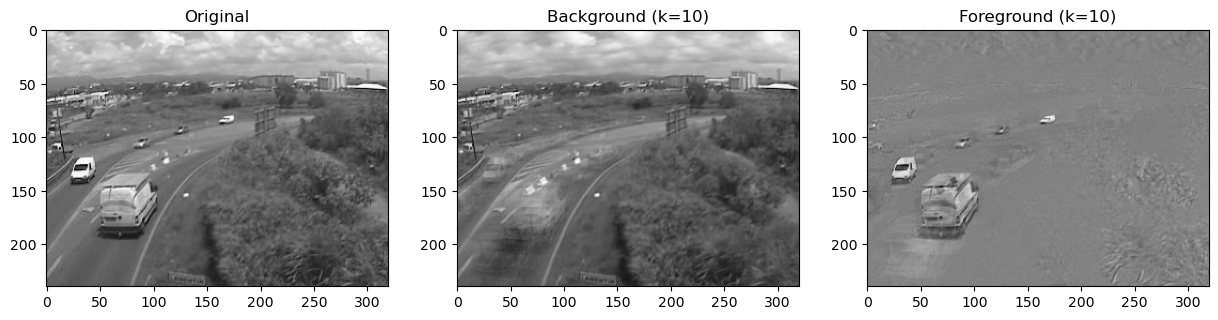

In [87]:
k = 10
num_of_frame = 100

X_k = reconstruct_background(U, S, Vt, k)
foreground = X - X_k

frame0 = X_k[:, num_of_frame].reshape(h, w)
foreground0 = foreground[:, num_of_frame].reshape(h, w)

plt.figure(figsize=(15,8))

plt.subplot(1,3,1)
plt.imshow(video[num_of_frame], cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(frame0, cmap='gray')
plt.title(f"Background (k={k})")

plt.subplot(1,3,3)
plt.imshow(foreground0, cmap='gray')
plt.title(f"Foreground (k={k})")

plt.show()

In [74]:
def normalize_frame(frame):
    frame = frame - frame.min()
    
    max_val = frame.max()
    if max_val > 0:
        frame = frame / max_val
    
    return (frame * 255).astype(np.uint8)

def threshold_frame(frame, thresh=30):
    return np.where(frame > thresh, frame, 0)

In [88]:
k = 7
X_k = reconstruct_background(U, S, Vt, k)
foreground = X - X_k
background = X_k

frames_fg = []
frames_bg = []

for i in range(n_frames):
    frame = foreground[:, i].reshape(h, w)
    frame = normalize_frame(frame)
    frame = threshold_frame(frame, 30)
    frames_fg.append(frame)

for i in range(n_frames):
    frame = background[:, i].reshape(h, w)
    frame = normalize_frame(frame)
    frames_bg.append(frame)

In [70]:
np.array(frames_fg).shape

(200, 240, 320)

In [66]:
def save_video(frames, path, fps=20):
    h, w = frames[0].shape

    out = cv2.VideoWriter(
        path,
        cv2.VideoWriter_fourcc(*'XVID'),
        fps,
        (w, h),
        isColor=False
    )

    for frame in frames:
        out.write(frame)

    out.release()

In [89]:
save_video(frames_fg, "../data/foreground.avi")
save_video(frames_bg, "../data/background.avi")

## Detection